In [ ]:
#this is my code for the upper dike analysis!

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
from scipy.optimize import curve_fit
from numpy import random

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path1 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-38-47.csv'
path2 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-39-38.csv'
path3 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-40-12.csv'
path4 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-41-11.csv'
path5 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-42-15.csv'
path6 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-42-57.csv'
path7 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-44-05.csv'
path8 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-44-45.csv'
path9 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-45-21.csv'
path10 = '/content/drive/MyDrive/anti_hazing_102/high/50/magnetometer_2025-09-13_12-46-09.csv'

#get paths to all 10 transects of the 50cm trials

In [5]:
#load data
L1 = pd.read_csv(path1)
L2 = pd.read_csv(path2)
L3 = pd.read_csv(path3)
L4 = pd.read_csv(path4)
L5 = pd.read_csv(path5)
L6 = pd.read_csv(path6)
L7 = pd.read_csv(path7)
L8 = pd.read_csv(path8)
L9 = pd.read_csv(path9)
L10 = pd.read_csv(path10)

alldata = [L1, L2, L3, L4, L5,  L6, L7, L8, L9, L10]

## Distance calibration: Assuming total transects are of equal length

In [8]:
# assume all transects go from 0m to 0.8m
# convert time column in data to distance column
for n in range(len(alldata)):
    time_list = alldata[n]["time"].tolist()
    get_distance = []
    for i in range(len(time_list)):
        seconds_since_midnight = time_list[i]
        if i==0:
            first_time = seconds_since_midnight
        distance = (seconds_since_midnight-first_time) / (len(time_list) * 0.1) * 8 # convert to m, largest t is 0.8 m
        get_distance.append(distance)

    alldata[n]['time'] = get_distance
    alldata[n] = alldata[n].rename(columns={"time":"distance"})

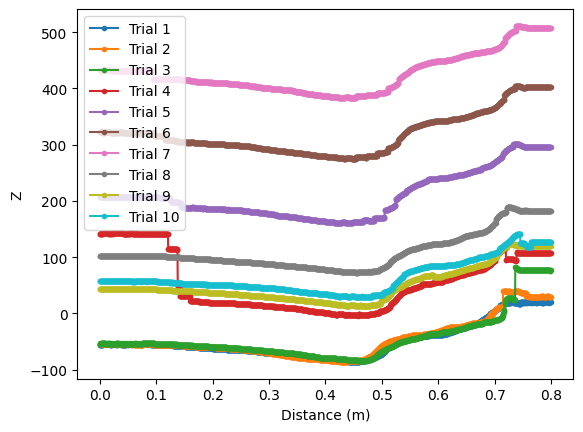

In [12]:
#PLOT ALL THE DATA

for i in range(len(alldata)):
    df = alldata[i]
    plt.plot(df["distance"], df["Bz"], marker='.', label=f"Trial {i+1}")

plt.legend()
plt.xlabel("Distance (m)")
plt.ylabel("Z")
plt.show()

In [14]:
# turn the data into a 2D grid to visualize changes in Bz along the dike

datagrid = []
for i in range(len(alldata)):
    # Original data points (x and y)
    index = i
    column = "Bz" # Looking at the z-component!
    transect_length = list(alldata[index]["distance"])[-1]
    x_original = list(alldata[index]["distance"])
    y_original = list(alldata[index][column])

    # New 1D grid
    x_new = np.linspace(0, transect_length, 100)

    # Use numpy.interp() to interpolate values onto the new grid
    y_interpolated = np.interp(x_new, x_original, y_original)

    # list of lists where every row is a transect
    datagrid.append(y_interpolated)
datagrid = np.array(datagrid)
# now it's an ndarray with each column being a transect
datagrid = datagrid.transpose()


# x coordinates for all the data points
one_row_xs = [0.2*x for x in range(0,len(datagrid[0]))]
all_xs = np.array([one_row_xs for x in range(0,len(datagrid))]).ravel()
# y coordinates for all the data points
distances_array = np.array(get_distance)
all_ys = np.tile(np.array([x_new]).transpose(), (1, len(datagrid[0]))).ravel()
# flatten the Bz_ndarray array:
Bz_flattened = datagrid.ravel()
# make sure everything is sized  correctly
print([len(x) for x in [all_xs, all_ys, Bz_flattened]])

# Create a grid on which to interpolate
xi, yi = np.meshgrid(np.linspace(0, one_row_xs[-1], 100), distances_array)

# Interpolate values at grid points using griddata
zi = griddata((all_xs, all_ys), Bz_flattened, (xi, yi), method='cubic')  # 'cubic' or 'linear' interpolation

[1000, 1000, 1000]


/tmp/ipython-input-184250625.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(xi, yi, zi, cmap='viridis', levels=50, alpha=0.75, label='Interpolated Data')


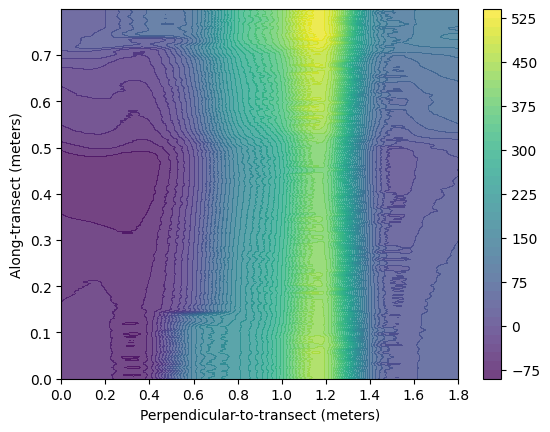

In [15]:
# Plot the interpolated grid
plt.contourf(xi, yi, zi, cmap='viridis', levels=50, alpha=0.75, label='Interpolated Data')

plt.xlabel('Perpendicular-to-transect (meters)')
plt.ylabel('Along-transect (meters)')
#plt.legend()
plt.colorbar()

plt.show()

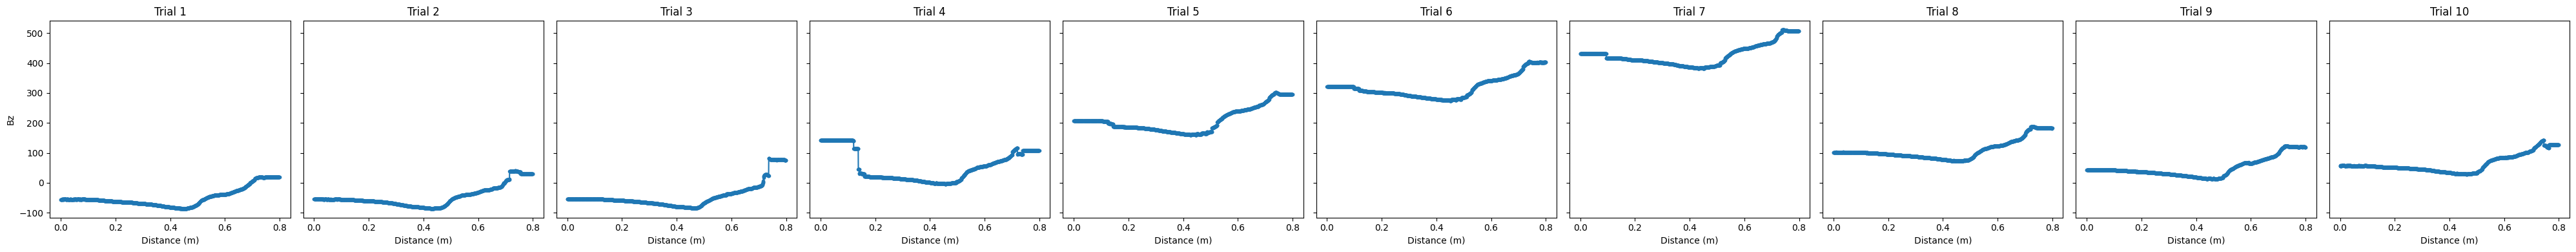

In [90]:
#PLOT ALL THE DATA SIDE BY SIDE

N = len(alldata)

fig, axes = plt.subplots(1, N, figsize=(4*N, 4), sharey=True)

for i, df in enumerate(alldata):
    ax = axes[i] if N > 1 else axes
    ax.plot(df["distance"], df["Bz"], marker='.')
    ax.set_title(f"Trial {i+1}")
    ax.set_xlabel("Distance (m)")
    if i == 0:
        ax.set_ylabel("Bz")

plt.tight_layout()
plt.show()

In [19]:
#this function was made with great help from AI. It is not the most beautiful, but the data structures
#it produces have been tested several times to check that the function actually does what it appears to do.

def align_transects(
    alldata,
    start_dist=0.2,
    end_dist=0.7,
    match_at="end",
    zero_at=None
):
    """
    Crop and align real transect data.

    Parameters
    ----------
    alldata : list of DataFrames
        Each must contain 'distance' and 'Bz'.
    start_dist : float
        Crop start distance.
    end_dist : float
        Crop end distance.
    match_at : str
        'begin', 'end', or 'middle'
        Used only if zero_at is None.
    zero_at : str or None
        If 'begin' → force Bz(start) = 0
        If 'end'   → force Bz(end) = 0
        If None    → align using match_at (original behavior)

    Returns
    -------
    aligned : list of DataFrames
            USEFUL FOR THE ANALYSIS

    reference_value : float
        Median (for match_at mode) OR 0 (for zero_at mode)
            HELPFUL FOR PLOTTING!
    """

    # -------------------------------------------------
    # 1. Crop - chop off the ends to remove problematic jumps, adds to cropped
    # -------------------------------------------------
    cropped = []
    for df in alldata:
        d = df[(df["distance"] >= start_dist) & (df["distance"] <= end_dist)].copy()
        cropped.append(d)

    # -------------------------------------------------
    # 2. Zero-at-mode (simple mode)
    # -------------------------------------------------
    if zero_at in ("begin", "end"):

        aligned = []

        for df in cropped:
            if zero_at == "begin":
                anchor_val = df["Bz"].iloc[0] #beginning of cropped trial

            elif zero_at == "end":
                anchor_val = df["Bz"].iloc[-1] #end of trial

            df2 = df.copy()
            df2["Bz"] = df["Bz"] - anchor_val
            aligned.append(df2)
        #align all trials at the end, then move to 0

        # reference value is 0 for zero-at mode
        reference_value = 0.0

        # Plot
        plt.figure(figsize=(10,8))
        for i, df in enumerate(aligned):
            plt.plot(df["distance"], df["Bz"], marker='.', label=f"Transect {i+1}")

        plt.axhline(0, color='k', linestyle='--', label=f"Bz=0 at {zero_at}")
        plt.xlabel("Distance (m)")
        plt.ylabel("Bz (aligned)")
        plt.title(f"Transects Zeroed at {zero_at} ({start_dist}-{end_dist} m)")
        plt.legend()
        plt.show()

        return aligned, reference_value

    # -------------------------------------------------
    # 3. match_at mode (median alignment) - align at median trial value @ beginning, middle, or end
    # -------------------------------------------------
    # Determine reference values
    if match_at == "begin":
        values = [df["Bz"].iloc[0] for df in cropped]

    elif match_at == "end":
        values = [df["Bz"].iloc[-1] for df in cropped]

    elif match_at == "middle":
        mid_dist = 0.5 * (start_dist + end_dist)
        values = [np.interp(mid_dist, df["distance"], df["Bz"]) for df in cropped]

    else:
        raise ValueError("match_at must be 'begin', 'end', or 'middle'")

    # Compute median
    reference_value = np.median(values)

    # Apply shifts
    aligned = []
    for df in cropped:

        if match_at == "begin":
            current = df["Bz"].iloc[0]

        elif match_at == "end":
            current = df["Bz"].iloc[-1]

        elif match_at == "middle":
            current = np.interp(mid_dist, df["distance"], df["Bz"])

        shift_amount = current - reference_value

        df2 = df.copy()
        df2["Bz"] = df["Bz"] - shift_amount
        aligned.append(df2)

    # Plot
    plt.figure(figsize=(10,8))
    for i, df in enumerate(aligned):
        plt.plot(df["distance"], df["Bz"], marker='.', label=f"Transect {i+1}")

    plt.axhline(reference_value, color='k', linestyle='--', label=f"Median ({match_at})")
    plt.xlabel("Distance (m)")
    plt.ylabel("Bz (aligned)")
    plt.title(f"Transects Aligned at {match_at} ({start_dist}-{end_dist} m)")
    plt.legend()
    plt.show()

    return aligned, reference_value

In [20]:
#THIS FUNCTION WAS MADE BECAUSE THE FIRST WAS NOT ENTIRELY USEFUL
#The model does not work well when final values, which should be 0 or negative, are instead positive

#made using AI, recycling most of the previous function

def align_to_first_middle(alldata, start_dist=0.2, end_dist=0.7):
    """
    Crop transects and align all of them vertically so that
    their value at the midpoint distance equals that of the
    FIRST transect at that midpoint.

    Parameters
    ----------
    alldata : list of DataFrames
        Each must contain 'distance' and 'Bz'.
    start_dist : float
        Crop start distance.
    end_dist : float
        Crop end distance.

    Returns
    -------
    aligned : list of DataFrames
        Cropped and aligned transects.
    ref_value : float
        The Bz value of the first transect at the midpoint,
        used as the alignment reference.
    """

    # 1. Crop all transects
    cropped = []
    for df in alldata:
        d = df[(df["distance"] >= start_dist) & (df["distance"] <= end_dist)].copy()
        cropped.append(d)

    # 2. Define the midpoint distance
    mid_dist = 0.5 * (start_dist + end_dist)

    # 3. Reference value: Bz of the FIRST transect at the midpoint
    first = cropped[0]
    ref_value = np.interp(mid_dist, first["distance"].values, first["Bz"].values)

    # 4. Align all transects to that reference
    aligned = []
    for df in cropped:
        current_mid = np.interp(mid_dist, df["distance"].values, df["Bz"].values)
        shift_amount = current_mid - ref_value

        df2 = df.copy()
        df2["Bz"] = df["Bz"] - shift_amount
        aligned.append(df2)

    # 5. Plot result
    plt.figure(figsize=(10,8))
    for i, df in enumerate(aligned):
        plt.plot(df["distance"], df["Bz"], marker='.', label=f"Transect {i+1}")

    plt.axvline(mid_dist, color='k', linestyle=':', alpha=0.5, label='Mid distance')
    plt.axhline(ref_value, color='k', linestyle='--', alpha=0.7,
                label='First transect value at mid')
    plt.xlabel("Distance (m)")
    plt.ylabel("Bz (aligned)")
    plt.title(f"Transects Aligned to Middle of First Run ({start_dist}-{end_dist} m)")
    plt.legend()
    plt.show()

    return aligned, ref_value

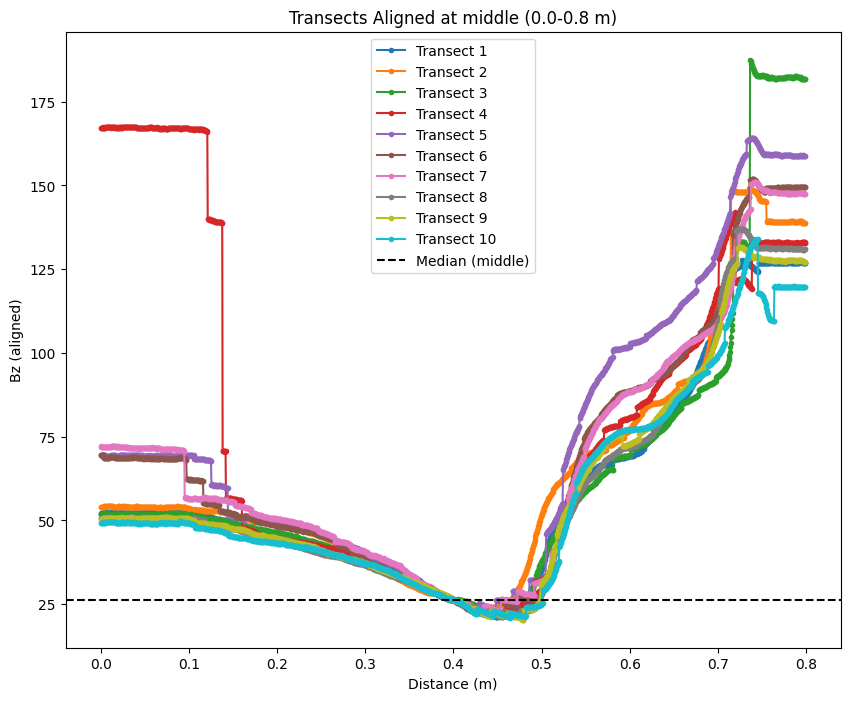

In [48]:
#ONE!
aligned, median_val = align_transects(alldata, 0.0, 0.8, match_at="middle")

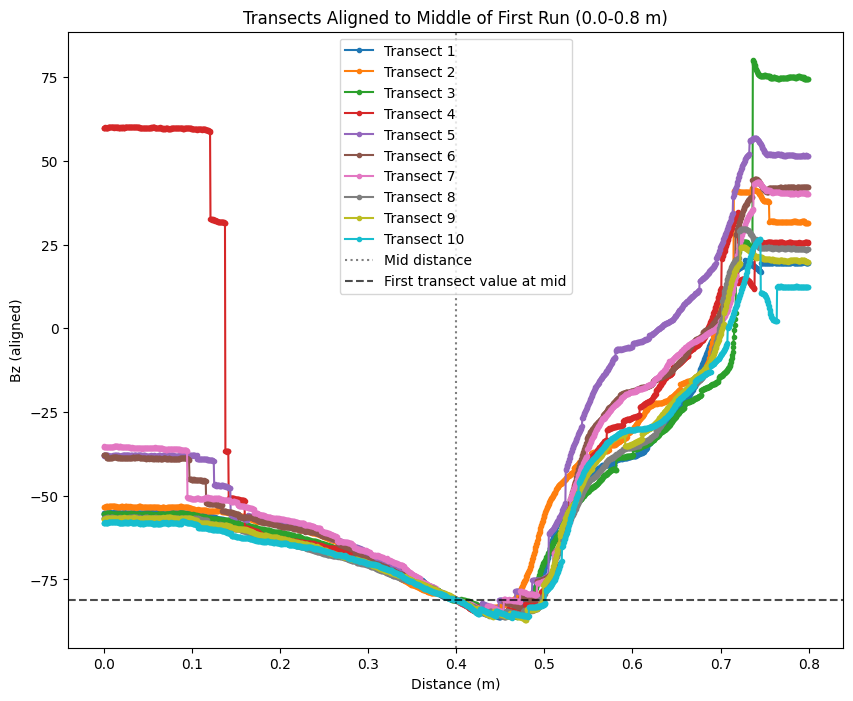

In [37]:
#TWO!
aligned, ref_val = align_to_first_middle(alldata, start_dist=0.0, end_dist=0.8)

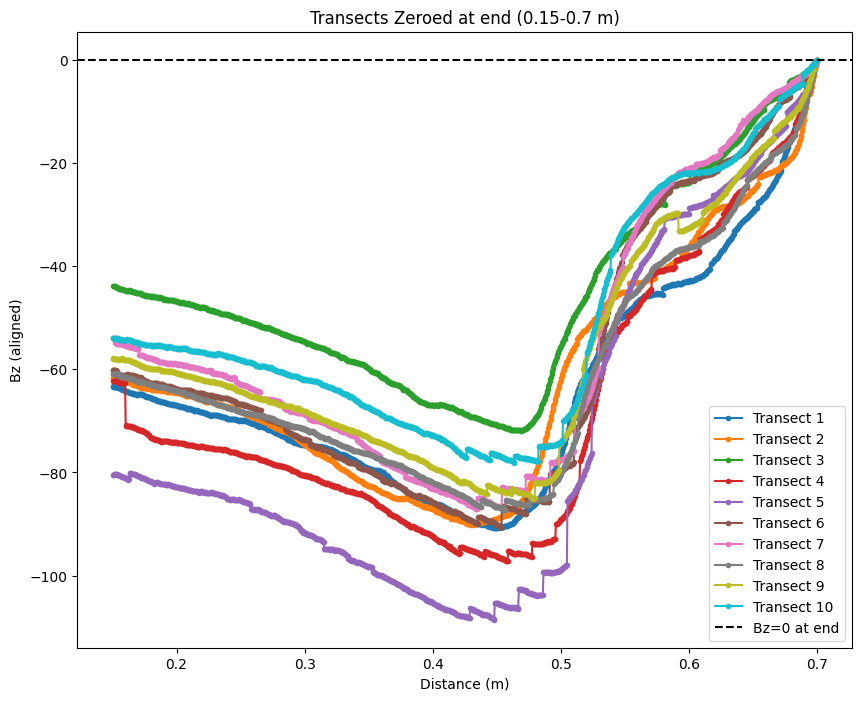

In [44]:
#THREE!
aligned, median_val = align_transects(alldata, 0.15, 0.7, zero_at="end")

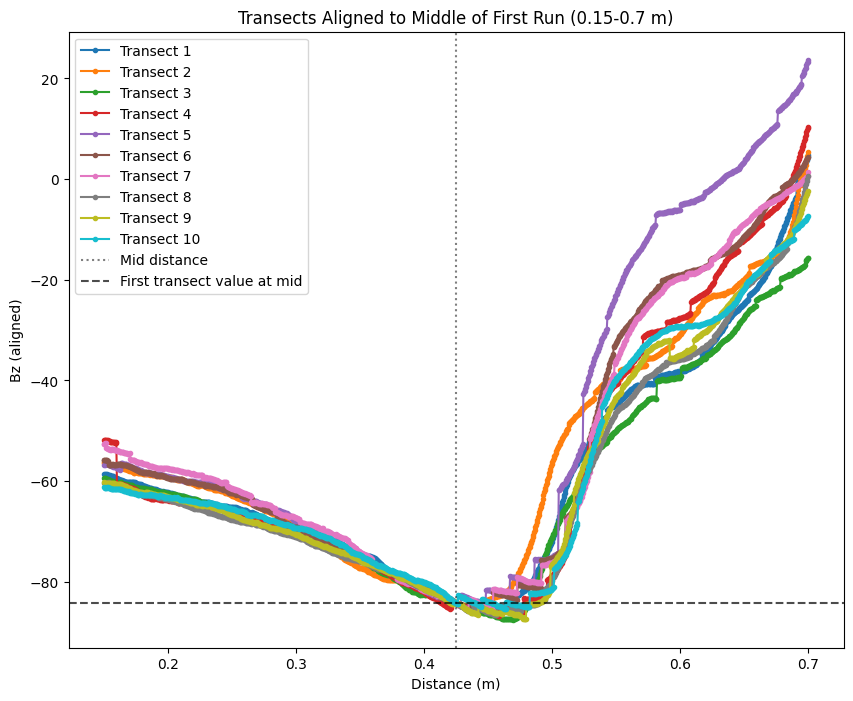

In [49]:
#FOUR!
aligned, ref_val = align_to_first_middle(alldata, start_dist=0.15, end_dist=0.7)

length 1178
length 1078
length 1123
length 1166
length 1144
length 1158
length 1151
length 1153
length 1164
length 1158
mean length: 1147.3
11473 total points


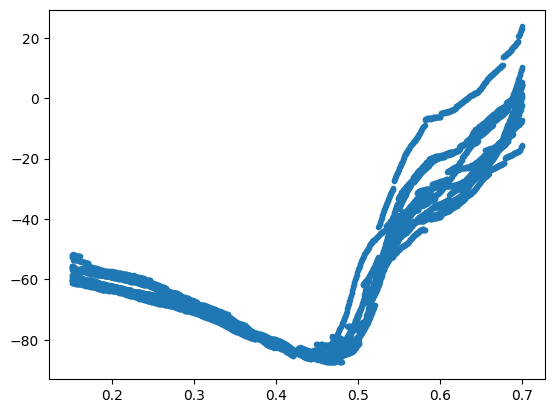

In [103]:
#just plot all the values, using a combined x_all and y_all

lengths = []

for df in aligned:
  n = len(df["distance"])
  print("length", n)
  lengths.append(n)

print("mean length:", np.mean(lengths))

x_all = np.concatenate([df["distance"].values for df in aligned])
y_all = np.concatenate([df["Bz"].values       for df in aligned])

print(len(x_all), "total points")
plt.plot(x_all, y_all, ".")

Fitted parameters:
dx = 0.285441948198457
ZZ = -0.02570919002287226
WW = 0.22832035710787973
phi = 77.94275253656363
JJ = 12.307201430399092
R² = 0.935


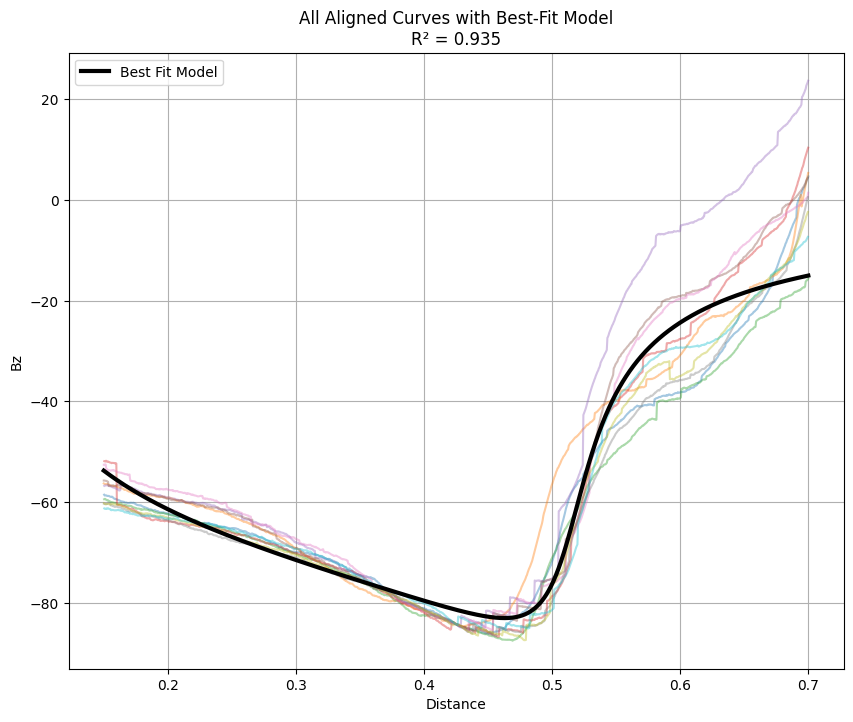

In [93]:
#function - given to model
def Bz_function(x, dx, ZZ, WW, phi, JJ):
    x_shift = x - dx
    term1 = np.cos(phi*np.pi/180) * np.log(((-WW + x_shift)**2 + ZZ**2) /
                                           ((WW + x_shift)**2 + ZZ**2))
    term2 = -np.sin(phi*np.pi/180) * np.arctan((x_shift - WW)/ZZ)
    term3 =  np.sin(phi*np.pi/180) * np.arctan((x_shift + WW)/ZZ)
    return 2 * JJ * (term1 + term2 + term3)

#starting guesses

WWtemp = 0.17  # width of the dike (m)
ZZtemp = 0.03  # height of phone above dike (m)
p0 = [-WWtemp, ZZtemp, WWtemp, 75, 10]

# Fit, save params
params, cov = curve_fit(Bz_function, x_all, y_all, p0=p0, maxfev=20000)
dx_fit, ZZ_fit, WW_fit, phi_fit, JJ_fit = params

#print params
print("Fitted parameters:")
print("dx =", dx_fit)
print("ZZ =", ZZ_fit)
print("WW =", WW_fit)
print("phi =", phi_fit)
print("JJ =", JJ_fit)

# -------------------------------------------------
# Compute goodness-of-fit (R²)
# -------------------------------------------------
y_pred = Bz_function(x_all, *params)

ss_res = np.sum((y_all - y_pred)**2)
ss_tot = np.sum((y_all - np.mean(y_all))**2)
r2 = 1 - ss_res/ss_tot
print(f"R² = {r2:.3f}")

# -------------------------------------------------
# Plot with R² in the title
# -------------------------------------------------
plt.figure(figsize=(10,8))

# plot each curve
for df in aligned:
    plt.plot(df["distance"], df["Bz"], alpha=0.4)

# plot best-fit model using sorted x
x_sorted = np.sort(x_all)
plt.plot(x_sorted, Bz_function(x_sorted, *params),
         'k-', lw=3, label='Best Fit Model')

plt.xlabel("Distance")
plt.ylabel("Bz")
plt.title(f"All Aligned Curves with Best-Fit Model\nR² = {r2:.3f}")
plt.legend()
plt.grid(True)
plt.show()

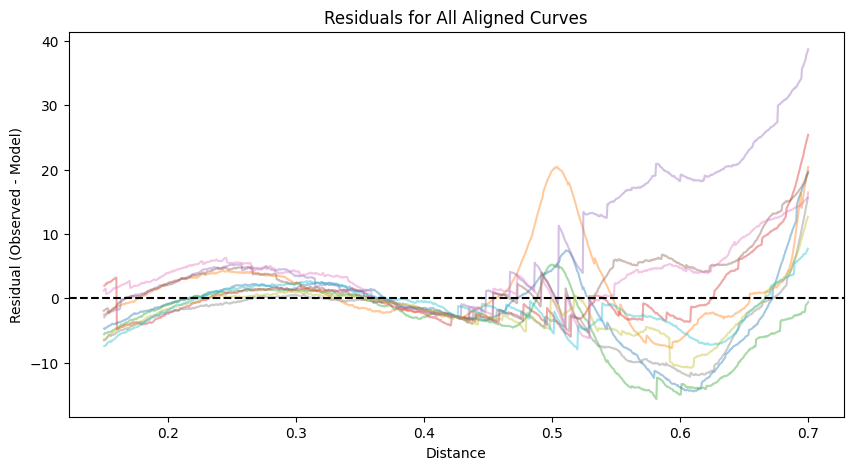

In [94]:
#PLOT RESIDUALS

plt.figure(figsize=(10,5))

for i, df in enumerate(aligned):
    x = df["distance"].values
    y = df["Bz"].values
    y_model = Bz_function(x, *params)
    residual = y - y_model
    plt.plot(x, residual, alpha=0.4)

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Distance")
plt.ylabel("Residual (Observed - Model)")
plt.title("Residuals for All Aligned Curves")
plt.show()

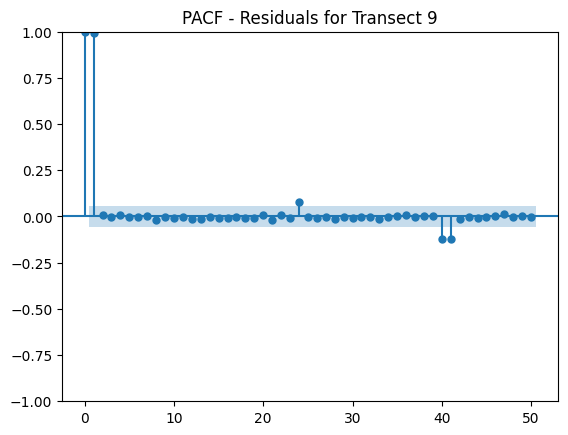

In [95]:
from statsmodels.graphics.tsaplots import plot_pacf

df = aligned[9] #pick one transect (in this case, trial 9)

res = df["Bz"].values - Bz_function(df["distance"].values, *params) #residuals

plot_pacf(res, lags=50)
plt.title("PACF - Residuals for Transect 9")
plt.show()

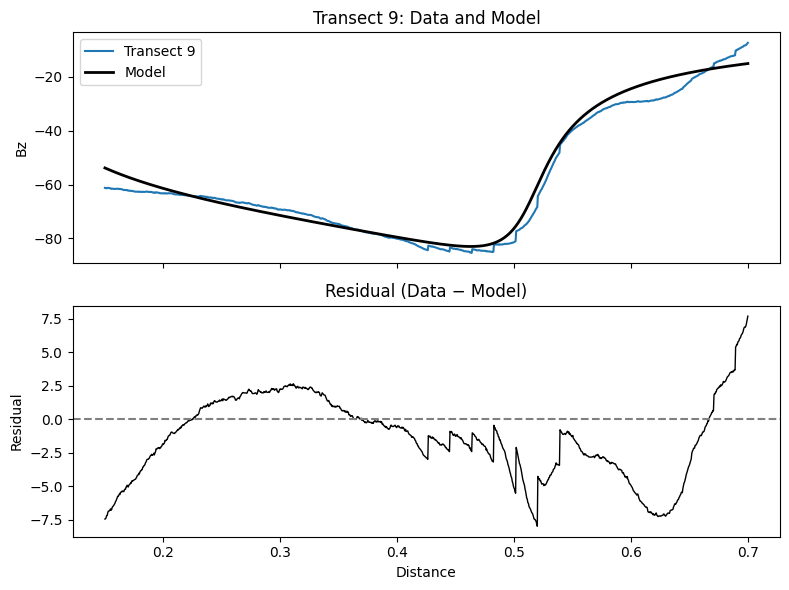

In [96]:
HOLD = 9

# pick transect
df = aligned[HOLD]
x = df["distance"].values
y = df["Bz"].values
y_model = Bz_function(x, *params)
res = y - y_model

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# --- top: data + model ---
axs[0].plot(x, y, '-', ms=3, label=f"Transect {HOLD}")
axs[0].plot(x, y_model, '-', color = "black", lw=2, label="Model")
axs[0].set_ylabel("Bz")
axs[0].set_title(f"Transect {HOLD}: Data and Model")
axs[0].legend()

# --- bottom: residuals ---
axs[1].plot(x, res, 'k-', lw=1)
axs[1].axhline(0, color='gray', linestyle='--')
axs[1].set_xlabel("Distance")
axs[1].set_ylabel("Residual")
axs[1].set_title("Residual (Data − Model)")

plt.tight_layout()
plt.show()

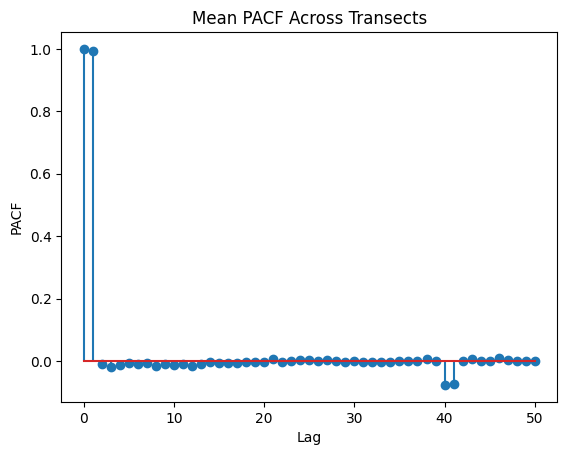

In [97]:
#PACF for all transects

from statsmodels.tsa.stattools import pacf

max_lag = 50
pacfs = []

for df in aligned:
    res = df["Bz"].values - Bz_function(df["distance"].values, *params)
    p = pacf(res, nlags=max_lag, method="ywm")
    pacfs.append(p)

mean_pacf = np.mean(pacfs, axis=0)

plt.stem(range(max_lag+1), mean_pacf)
plt.title("Mean PACF Across Transects")
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.show()

In [98]:
#TRY AUTO ARIMA - FIND THE ORDER, WAS FOUND TO BE 1, 0, 1

#this part uses AI. 1, 0, 1 is not actually used later, though.

import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

# res_all is your residual series
res_all = res_all - res_all.mean()

# 1) Let pmdarima find a good (p,d,q)
auto_model = pm.auto_arima(
    res_all,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=0,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())
print("Selected order:", auto_model.order)

# 2) Optionally refit the same order with statsmodels ARIMA
best_order = auto_model.order
ar_model = ARIMA(res_all, order=best_order).fit()
print(ar_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=74892.589, Time=0.17 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.28 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=60851.291, Time=1.15 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=25791.249, Time=0.62 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=25793.243, Time=0.77 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=25793.243, Time=0.84 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=51055.382, Time=3.19 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.54 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=25795.232, Time=6.53 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=25793.248, Time=2.29 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0]          
Total fit time: 16.409 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                11473
Model:               SARIMAX(1, 0, 1)   Log Likelihood         

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                11473
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -12892.768
Date:                Fri, 12 Dec 2025   AIC                          25791.537
Time:                        23:37:08   BIC                          25813.580
Sample:                             0   HQIC                         25798.948
                              - 11473                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3235      1.884      0.172      0.864      -3.368       4.015
ar.L1          0.9931      0.002    633.952      0.000       0.990       0.996
sigma2         0.5539      0.002    351.468      0.0

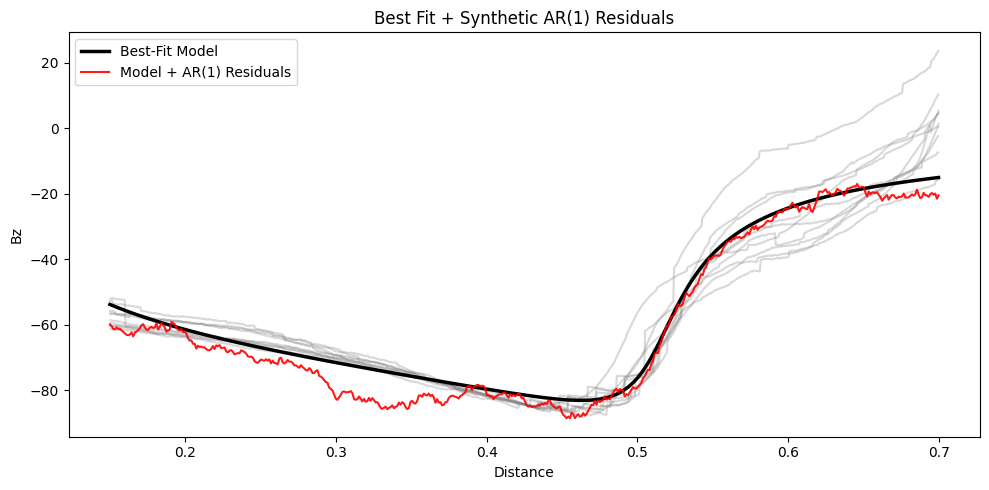

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

#THIS GENERATES PLOTS THAT SHOW WHAT THE RESIDUALS APPEAR LIKE
#BUT SPECIFICALLY USING A GIVEN NUMBER OF POINTS

res_all = np.concatenate([
    df["Bz"].values - Bz_function(df["distance"].values, *params)
    for df in aligned
])

plt.figure(figsize=(10, 5))

# Fit AR(1) model to pooled residuals
ar_model = ARIMA(res_all, order=(1,0,0)).fit()
print(ar_model.summary())

# x-grid over the full data range
x_min = min(df["distance"].min() for df in aligned)
x_max = max(df["distance"].max() for df in aligned)

# e.g., 500 points between ~0.15 and ~0.7
x_grid = np.linspace(x_min, x_max, 500)
N = len(x_grid)

# Simulate synthetic AR(1) residuals on this grid
res_syn = ar_model.simulate(nsimulations=N)  # length N residual series

# smooth best fit curve on grid
y_model_grid = Bz_function(x_grid, *params)

# Synthetic curve = smooth model + synthetic residuals
y_synth = y_model_grid + res_syn


#real curves
for df in aligned:
    plt.plot(df["distance"], df["Bz"], color='gray', alpha=0.3)

plt.plot(x_grid, y_model_grid, 'k-', lw=2.5, label='Best-Fit Model')
plt.plot(x_grid, y_synth, 'r-', lw=1.5, alpha=0.9, label='Model + AR(1) Residuals')
plt.xlabel("Distance")
plt.ylabel("Bz")
plt.title("Best Fit + Synthetic AR(1) Residuals")
plt.legend()
plt.tight_layout()
plt.show()


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                11473
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -12892.768
Date:                Fri, 12 Dec 2025   AIC                          25791.537
Time:                        23:26:07   BIC                          25813.580
Sample:                             0   HQIC                         25798.948
                              - 11473                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3235      1.884      0.172      0.864      -3.368       4.015
ar.L1          0.9931      0.002    633.952      0.000       0.990       0.996
sigma2         0.5539      0.002    351.468      0.0

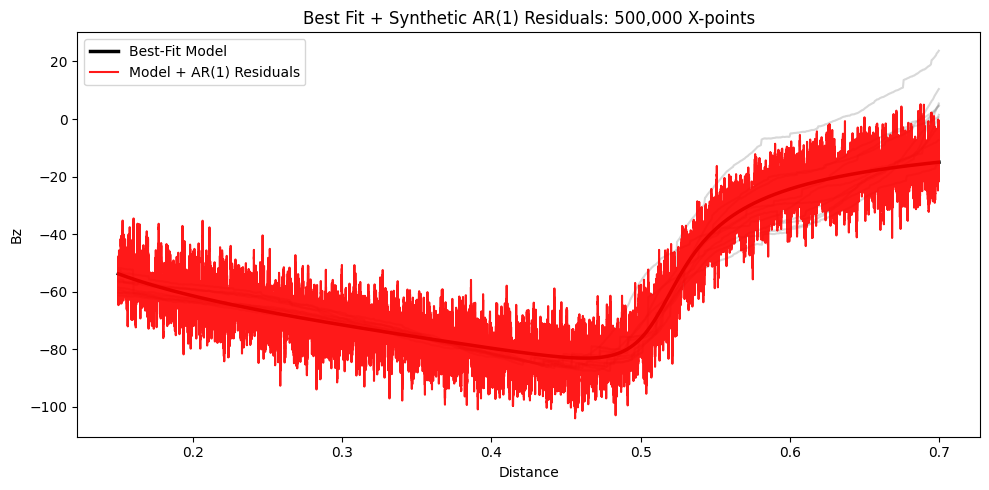

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

res_all = np.concatenate([
    df["Bz"].values - Bz_function(df["distance"].values, *params)
    for df in aligned
])

plt.figure(figsize=(10, 5))

# Fit AR(1) model to pooled residuals
ar_model = ARIMA(res_all, order=(1,0,0)).fit()
print(ar_model.summary())

# x-grid over the full data range
x_min = min(df["distance"].min() for df in aligned)
x_max = max(df["distance"].max() for df in aligned)

# 500,000
x_grid = np.linspace(x_min, x_max, 500000)
N = len(x_grid)

# Simulate synthetic AR(1) residuals on this grid
res_syn = ar_model.simulate(nsimulations=N)  # length N residual series

# smooth best fit curve on grid
y_model_grid = Bz_function(x_grid, *params)

# Synthetic curve = smooth model + synthetic residuals
y_synth = y_model_grid + res_syn


#real curves
for df in aligned:
    plt.plot(df["distance"], df["Bz"], color='gray', alpha=0.3)

plt.plot(x_grid, y_model_grid, 'k-', lw=2.5, label='Best-Fit Model')
plt.plot(x_grid, y_synth, 'r-', lw=1.5, alpha=0.9, label='Model + AR(1) Residuals')
plt.xlabel("Distance")
plt.ylabel("Bz")
plt.title("Best Fit + Synthetic AR(1) Residuals: 500,000 X-points")
plt.legend()
plt.tight_layout()
plt.show()


0.150044671346522 0.6999182720373613
Effective bootstrap samples: 2000
phi original       = 77.94
phi bootstrap mean = 77.93
phi bootstrap sd   = 4.046
phi 95% CI (perc)  = [69.79, 85.29]


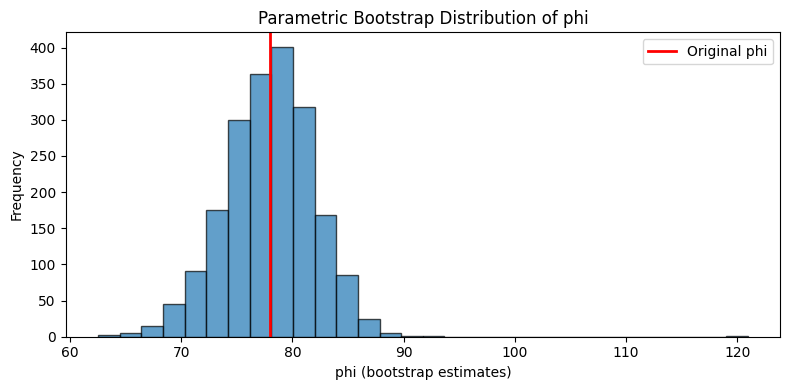

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy.optimize import curve_fit

# ---------- 2. Define x-grid over data range (fixed for bootstrap) ----------
x_min = min(df["distance"].min() for df in aligned)
x_max = max(df["distance"].max() for df in aligned)

x_grid = np.linspace(x_min, x_max, 1147)   # choose resolution
N_grid = len(x_grid)
print(x_min, x_max)

# Precompute smooth model on this grid (deterministic part)
y_model_grid = Bz_function(x_grid, *params)

# ---------- 3. Bootstrap loop ----------
n_boot = 2000   # number of bootstrap replicates
phi_boot = []   # store phi estimates
params_boot = []  # optionally store all parameters

# Initial guess for nonlinear fit; use original params
p0 = params

for b in range(n_boot):
    # --- 3.a Simulate one AR(1) residual sequence of length N_grid ---
    res_syn = ar_model.simulate(nsimulations=N_grid)

    # --- 3.b Construct synthetic Bz data on x_grid ---
    y_synth = y_model_grid + res_syn

    # --- 3.c Refit nonlinear model to synthetic data ---
    # curve_fit returns popt (fitted params) and pcov
    try:
        popt, pcov = curve_fit(
            Bz_function,
            x_grid,
            y_synth,
            p0=p0,
            maxfev=10000   # increase if nonlinearity is strong
        )
    except RuntimeError:
        # Fit failed to converge; you can skip or handle differently
        # For now, just skip this replicate
        continue

    params_boot.append(popt)
    phi_boot.append(popt[3])  # adjust index if phi is another element

phi_boot = np.array(phi_boot)
params_boot = np.array(params_boot)

print(f"Effective bootstrap samples: {len(phi_boot)}")

# ---------- 4. Summaries for phi ----------
phi_mean = np.mean(phi_boot)
phi_std = np.std(phi_boot, ddof=1)
phi_ci = np.percentile(phi_boot, [2.5, 97.5])

print(f"phi original       = {params[3]:.4g}")
print(f"phi bootstrap mean = {phi_mean:.4g}")
print(f"phi bootstrap sd   = {phi_std:.4g}")
print(f"phi 95% CI (perc)  = [{phi_ci[0]:.4g}, {phi_ci[1]:.4g}]")

# ---------- 5. Plot bootstrap distribution of phi ----------
plt.figure(figsize=(8,4))
plt.hist(phi_boot, bins=30, alpha=0.7, color='C0', edgecolor='k')
plt.axvline(params[3], color='r', lw=2, label='Original phi')
plt.xlabel("phi (bootstrap estimates)")
plt.ylabel("Frequency")
plt.title("Parametric Bootstrap Distribution of phi")
plt.legend()
plt.tight_layout()
plt.show()

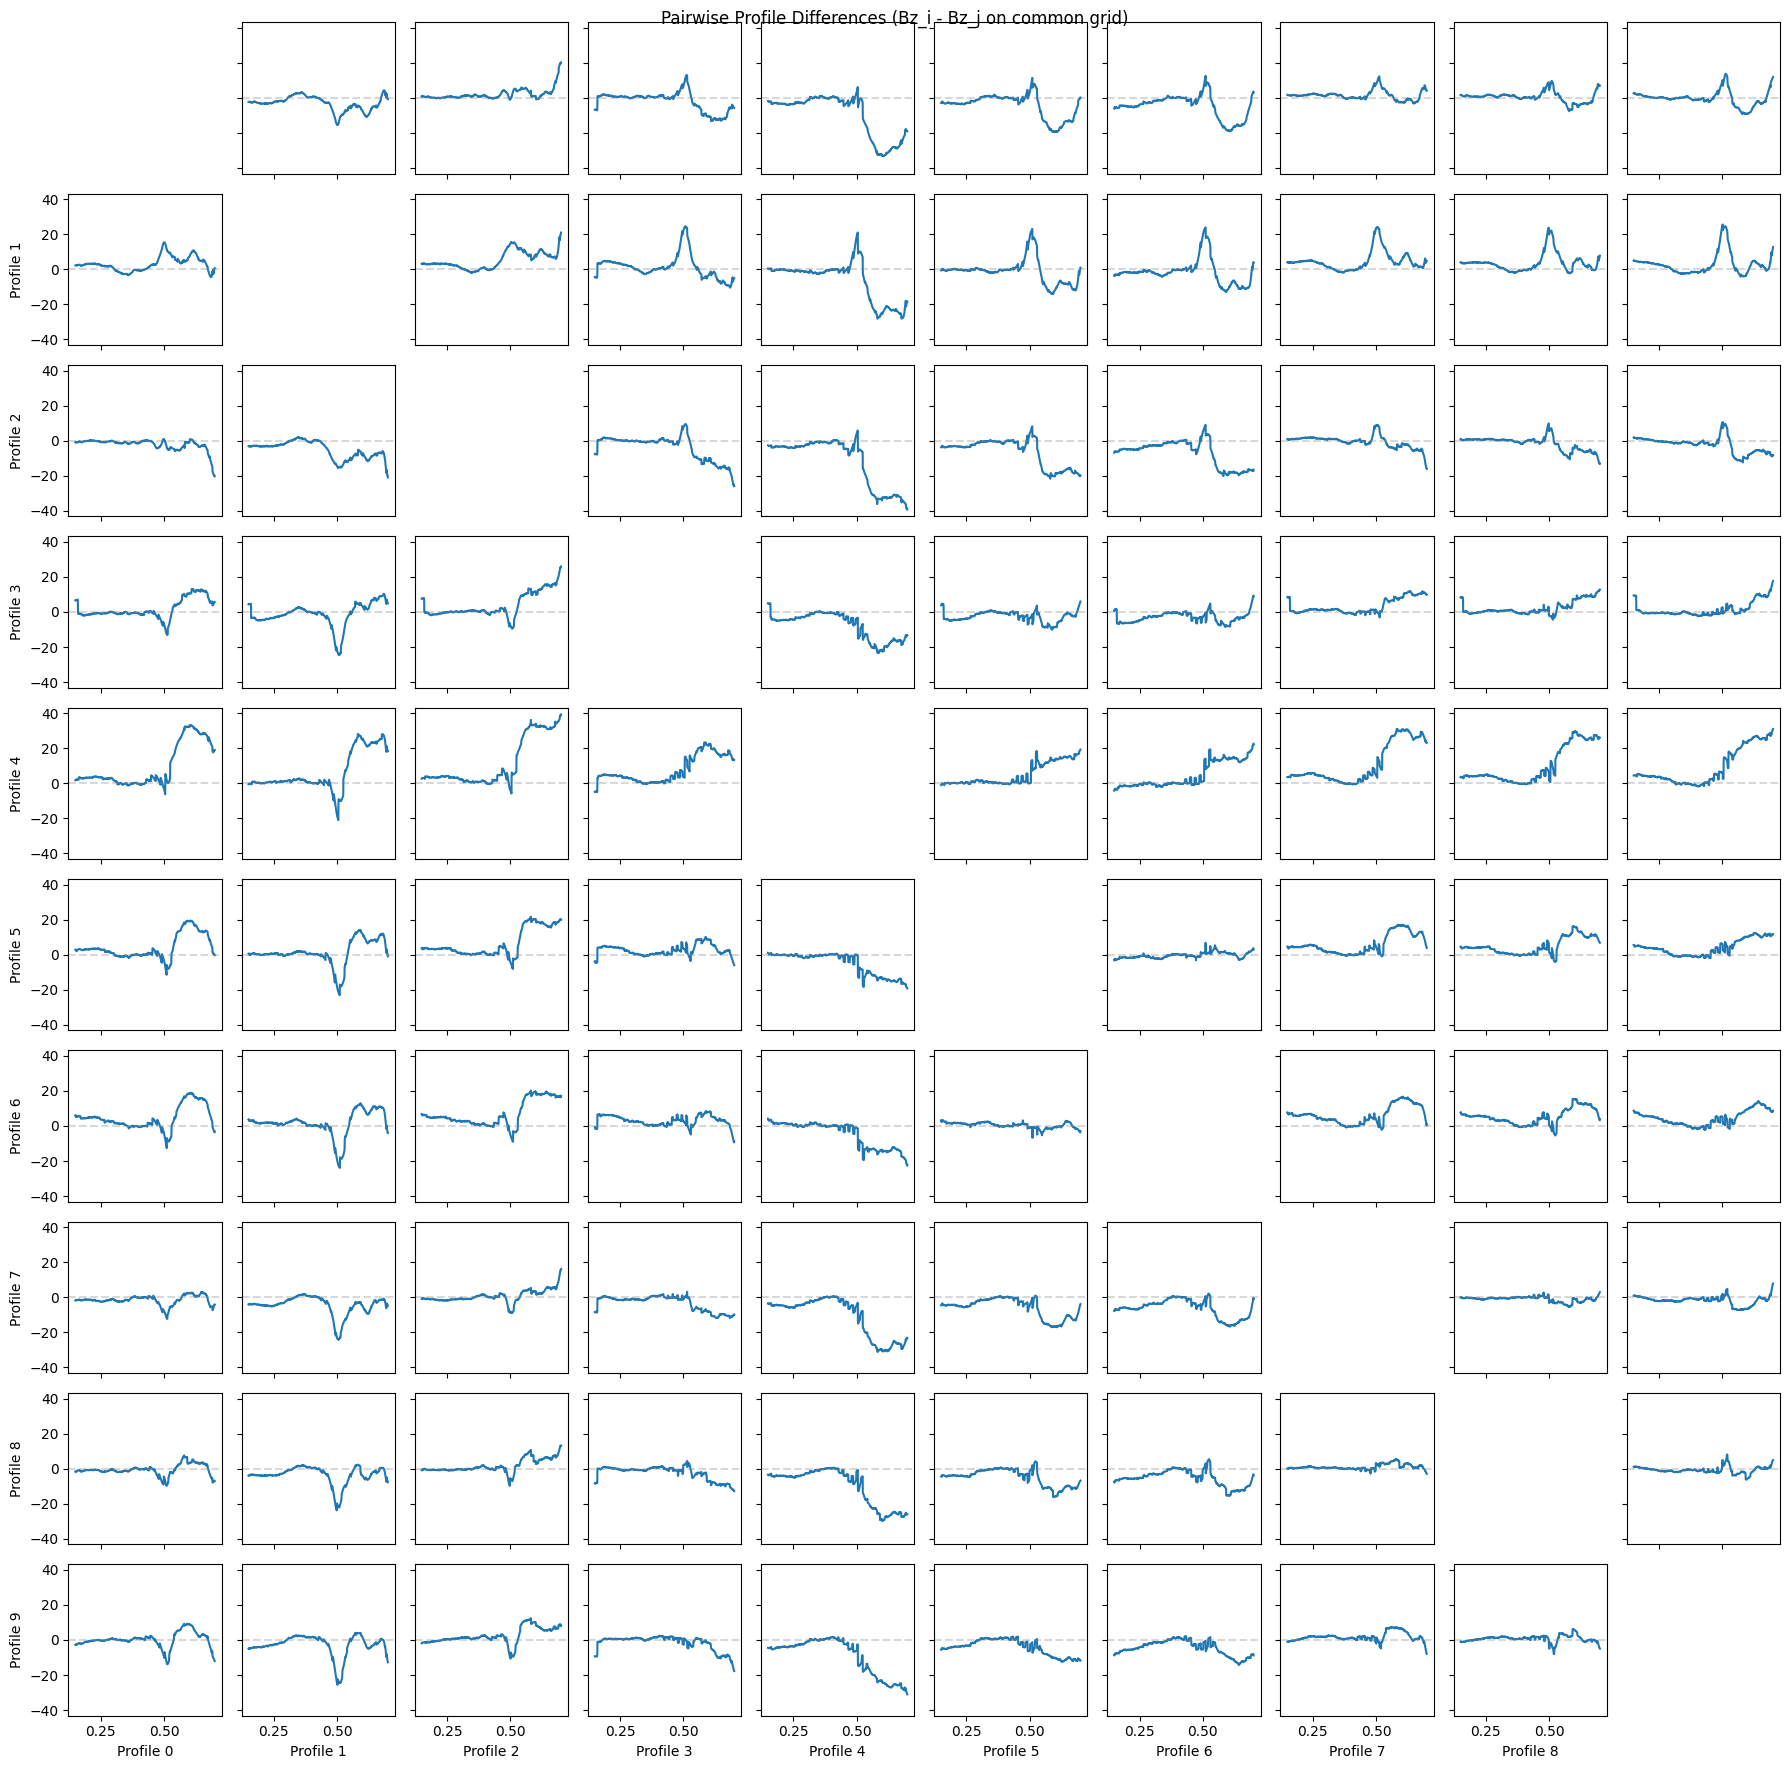

In [110]:
#compare each transect to each other transect, so that we can compare
#if rushing/dragging occurrs in any easily quantifiable pattern.


#this part heavily used AI, but then was modified because AI gave me incorrect labels.

#note: we use the transects in aligned, which are already centered at one point in the middle.
#they should be centered there anyway, since we had a metronome that marked
#regular intervals, one of which should corrospond to that point

#grid
x_min = min(df["distance"].min() for df in aligned)
x_max = max(df["distance"].max() for df in aligned)
N = 1000 #because the actual transects are
x_grid = np.linspace(x_min, x_max, N)

#put each trial in aligned on the grid
profiles = []
for df in aligned:
    x = df["distance"].values
    y = df["Bz"].values
    # sort by x, in case not sorted (distance)
    idx = np.argsort(x)
    x_sorted = x[idx]
    y_sorted = y[idx]
    # interpolate
    y_interp = np.interp(x_grid, x_sorted, y_sorted)
    profiles.append(y_interp)

profiles = np.array(profiles)  # shape: (n_profiles, N)
n_profiles = profiles.shape[0]
indices = range(n_profiles)

# 3. Make pairwise difference plot (like your col_indices code)
fig, axs = plt.subplots(n_profiles, n_profiles, figsize=(18, 18),
                        sharex=True, sharey=True, squeeze=False)

for i in range(n_profiles):
    for j in range(n_profiles):
        if i == j:
            axs[i, j].axis('off')
            continue

        prof_i = profiles[i]
        prof_j = profiles[j]

        axs[i, j].plot(x_grid, prof_i - prof_j)
        axs[i, j].axhline(0, color='gray', linestyle='--', alpha=0.3)

        # bottom row: label columns
        if i == n_profiles - 1:
            axs[i, j].set_xlabel(f'Profile {j}')
        # first column: label rows
        if j == 0:
            axs[i, j].set_ylabel(f'Profile {i}')

plt.suptitle("Pairwise Profile Differences (Bz_i - Bz_j on common grid)")
plt.tight_layout()
plt.show()